In [63]:
warnings.filterwarnings('ignore', category=RuntimeWarning)

<>:206: SyntaxWarning: invalid escape sequence '\p'
<>:206: SyntaxWarning: invalid escape sequence '\p'
C:\Users\risha\AppData\Local\Temp\ipykernel_17960\2997191751.py:206: SyntaxWarning: invalid escape sequence '\p'
  ax1.plot(x_vec, psi_sq_scaled, 'r', label=f"Bound State $\psi_{{{bound_state_index}}}$ (E={np.real(bound_state_energy):.2f})")


--- 1. Building Discretized NON-HERMITIAN Hamiltonian ---
Grid: 800 points from x = -10.0 to +10.0
Potential: V(x) = -(1.0*cosh^4.0x + ...) + i(0.05*sinh x + ...)
... Complex H matrix built.
--- 2. Diagonalizing 800x800 Complex H Matrix ---
... (This may take a moment, using general solver 'linalg.eig') ...
... Diagonalization complete in 1.15 s
--- 3. Finding Trapped Ground State ---
Searching all 800 eigenstates for minimum <x^2>...
Found TRAPPED bound state at index 297
Energy E_B = 6382.2238-0.0000j  (Note: May be complex!)
<x^2> = 0.2204 (Confirms localization in center)
--- 4. Building X and P Matrices (Biorthogonal Basis) ---
... X_eb and P_eb built (using C_inv).
--- 5. Calculating Microcanonical OTOC for State 297 ---
... OTOC calculation complete in 12.38 s

---  Plotting Results ---


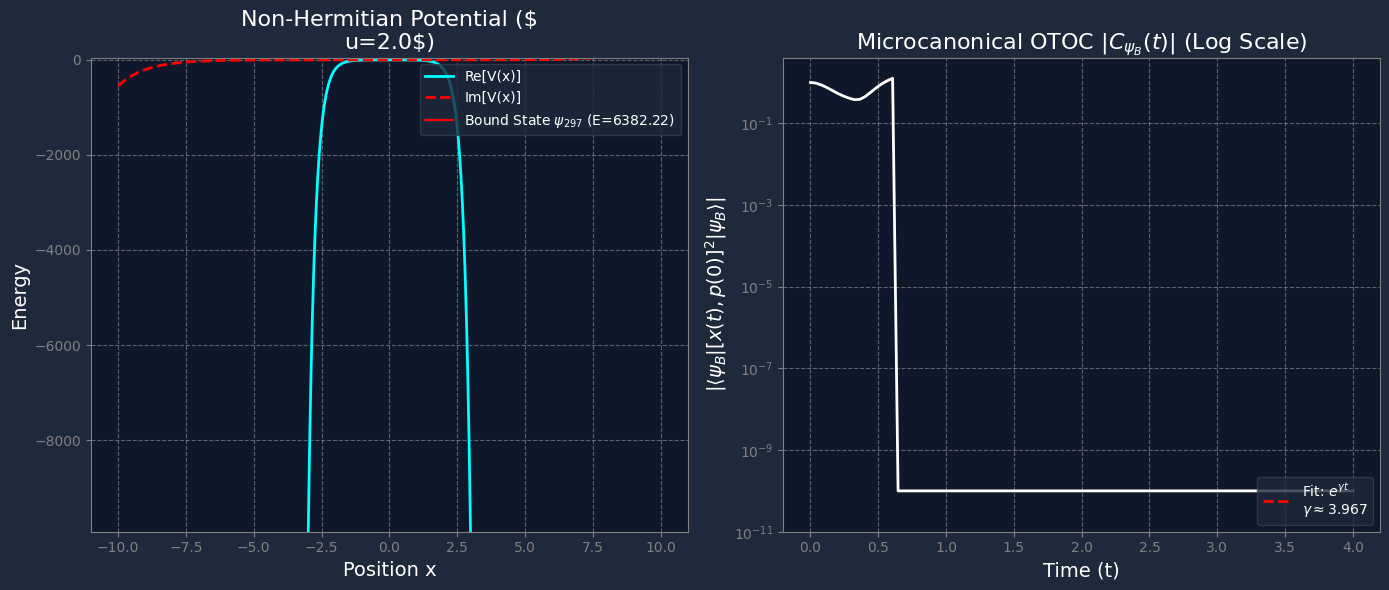

In [1]:
import numpy as np
import scipy.linalg as linalg
import matplotlib.pyplot as plt
import time
import warnings

# --- 0. Setup and Parameters ---

# Suppress warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=np.ComplexWarning)

# Grid parameters
N_points = 800     
L = 10.0          # A wider grid
x_vec = np.linspace(-L, L, N_points)
dx = x_vec[1] - x_vec[0]

# Physics parameters
hbar = 1.0
m = 0.5
hbar_sq_over_2m = hbar**2 / (2.0 * m)

# Potential parameters
nu = 2.0
a1 = 1.0
a2 = 1.0 


V3 = 0.05  # Strength of the i*sinh(x) term
V4 = 0.0   # Keep this one simple for now

def sech(x):
    return 1 / np.cosh(x)



def get_potential(x, a1, a2, nu, V3, V4):
    """
    Returns the original, unbounded, NON-HERMITIAN volcano potential
    V(x) = V_real(x) + V_imag(x)
    """
    # Real Part (unbounded)
    cosh_term = np.cosh(x)**(2.0 * nu)
    sech_term = sech(x)**2
    V_real = -(a1 * cosh_term + a2 * sech_term)
    
    # Imaginary Part (PT-Symmetric)
    sinh_term = np.sinh(x)
    sech_tanh_term = sech(x) * np.tanh(x)
    V_imag = 1j * (V3 * sinh_term + V4 * sech_tanh_term)
    
    V_raw = V_real + V_imag
    
   
    V_real_at_zero = -(a1 + a2)
    return V_raw - V_real_at_zero

print(f"--- 1. Building Discretized NON-HERMITIAN Hamiltonian ---")
print(f"Grid: {N_points} points from x = -{L} to +{L}")
print(f"Potential: V(x) = -({a1}*cosh^{2*nu}x + ...) + i({V3}*sinh x + ...)")

V_x = get_potential(x_vec, a1, a2, nu, V3, V4)
V_mat = np.diag(V_x) # V_mat is now complex

# Build Kinetic Matrix T = -hbar^2/(2m) * d^2/dx^2 (Real, Symmetric)
T_mat = np.zeros((N_points, N_points))
diag_val = 2.0 * hbar_sq_over_2m / (dx**2)
off_diag_val = -1.0 * hbar_sq_over_2m / (dx**2)
np.fill_diagonal(T_mat, diag_val)
np.fill_diagonal(T_mat[1:], off_diag_val)
np.fill_diagonal(T_mat[:, 1:], off_diag_val)

# H_mat is now COMPLEX and NON-HERMITIAN
H_mat = T_mat + V_mat
print("... Complex H matrix built.")


print(f"--- 2. Diagonalizing {N_points}x{N_points} Complex H Matrix ---")
print("... (This may take a moment, using general solver 'linalg.eig') ...")
start_time = time.time()

eigenvalues, right_eigenvectors = linalg.eig(H_mat)
end_time = time.time()
print(f"... Diagonalization complete in {end_time - start_time:.2f} s")


print(f"--- 3. Finding Trapped Ground State ---")


min_x_sq = np.inf
bound_state_index = -1
bound_state_energy = np.inf

print(f"Searching all {N_points} eigenstates for minimum <x^2>...")
for i in range(N_points): # Iterate over ALL states
    psi_i = right_eigenvectors[:, i]
  
    norm_sq = np.sum(np.abs(psi_i)**2) * dx
    
    
    if norm_sq < 1e-15:
        continue
        
    psi_i_norm = psi_i / np.sqrt(norm_sq) # Manually normalize for <x^2>
    
    x_sq_i = np.sum(np.abs(psi_i_norm)**2 * x_vec**2) * dx
    
    if x_sq_i < min_x_sq:
        min_x_sq = x_sq_i
        bound_state_index = i
        bound_state_energy = eigenvalues[i]

if bound_state_index == -1:
    print("FATAL ERROR: Could not find a bound state.")
    # Stop execution
else:
    print(f"Found TRAPPED bound state at index {bound_state_index}")
    print(f"Energy E_B = {bound_state_energy:.4f}  (Note: May be complex!)")
    print(f"<x^2> = {min_x_sq:.4f} (Confirms localization in center)")

    
# --- 4. Build X and P Matrices in the Energy Basis ---
print("--- 4. Building X and P Matrices (Biorthogonal Basis) ---")
# The basis C is non-orthogonal, so C_dagger != C_inv
C = right_eigenvectors
try:
    C_inv = linalg.inv(C)
except linalg.LinAlgError:
    print("FATAL ERROR: Eigenvector matrix C is singular. Cannot invert.")

    raise SystemExit

X_pos_basis = np.diag(x_vec)

P_mat_real = np.zeros((N_points, N_points))
off_diag_p = 1.0 / (2.0 * dx)
np.fill_diagonal(P_mat_real[1:], off_diag_p)
np.fill_diagonal(P_mat_real[:, 1:], -off_diag_p)
P_pos_basis = -1j * hbar * P_mat_real


# X_eb = C_inv @ X_pos_basis @ C
# P_eb = C_inv @ P_pos_basis @ C
X_eb = C_inv @ X_pos_basis @ C
P_eb = C_inv @ P_pos_basis @ C

# H is diagonal in this basis
H_eb = np.diag(eigenvalues)

print("... X_eb and P_eb built (using C_inv).")


print(f"--- 5. Calculating Microcanonical OTOC for State {bound_state_index} ---")
t_values = np.linspace(0, 4.0, 100)
otoc_values = []


B_idx = bound_state_index




E_m_matrix = np.tile(eigenvalues, (N_points, 1)).T
E_n_matrix = np.tile(eigenvalues, (N_points, 1))
E_diff_matrix = E_n_matrix - E_m_matrix

start_time = time.time()
for t in t_values:
   
    U_t_matrix = np.exp(-1j * E_diff_matrix * t / hbar)
    X_t_eb = X_eb * U_t_matrix
    
    # Commutator [X(t), P(0)] in energy basis
    Comm_t_eb = (X_t_eb @ P_eb) - (P_eb @ X_t_eb)
 
    OTOC_op_eb = - (Comm_t_eb @ Comm_t_eb)
    
    
    otoc_value = OTOC_op_eb[B_idx, B_idx]
    
   
    otoc_values.append(np.abs(otoc_value))

end_time = time.time()
print(f"... OTOC calculation complete in {end_time - start_time:.2f} s")



print("\n---  Plotting Results ---")
plt.figure(figsize=(14, 6))

# Plot 1: The Potential and Bound State
ax1 = plt.subplot(1, 2, 1)
ax1.plot(x_vec, np.real(V_x), color='cyan', lw=2, label="Re[V(x)]")
ax1.plot(x_vec, np.imag(V_x), color='red', lw=2, linestyle='--', label="Im[V(x)]")
ax1.set_title(f"Non-Hermitian Potential ($\nu={nu}$)", fontsize=16)
ax1.set_xlabel("Position x", fontsize=14)
ax1.set_ylabel("Energy", fontsize=14)

# Plot the bound state we found
psi_B_pos = right_eigenvectors[:, bound_state_index]

plot_scale = 10.0 / np.max(np.abs(psi_B_pos)**2) # Scale for visibility
psi_sq_scaled = plot_scale * np.abs(psi_B_pos)**2 + np.real(bound_state_energy)
ax1.plot(x_vec, psi_sq_scaled, 'r', label=f"Bound State $\psi_{{{bound_state_index}}}$ (E={np.real(bound_state_energy):.2f})")

ax1.set_ylim(np.min(np.real(V_x[np.abs(x_vec) < 3])) - 10, 50) # Zoom in
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: The OTOC
ax2 = plt.subplot(1, 2, 2)
otoc_plot_values = np.array(otoc_values)
t_plot = t_values

small_positive = 1e-10
non_positive_mask = (otoc_plot_values <= 0) | (~np.isfinite(otoc_plot_values))
otoc_plot_values[non_positive_mask] = small_positive

plot_label = "Fit: N/A"
try:
    fit_start_t, fit_end_t = 0.5, 1.5
    fit_mask = (t_plot >= fit_start_t) & (t_plot <= fit_end_t) & (otoc_plot_values > small_positive)
    
    t_fit = t_plot[fit_mask]
    C_fit_log = np.log(otoc_plot_values[fit_mask])

    if len(t_fit) > 2:
        m, c = np.polyfit(t_fit, C_fit_log, 1)
        if np.isfinite(m):
           
            lambda_growth = m # Note: not m/2, as C ~ |...|^2 ~ (e^Et)^2 = e^2Et
            fit_line = np.exp(m * t_fit + c)
            ax2.plot(t_fit, fit_line, 'r--', lw=2, label=rf"Fit: $e^{{\gamma t}}$" + "\n" + rf"$\gamma \approx {lambda_growth:.3f}$")
    else:
        ax2.plot([], [], 'r--', lw=2, label="Fit: N/M (Not enough data)")
except Exception as e:
    print(f"Warning: Could not perform exponential fit. Error: {e}")
    ax2.plot([], [], 'r--', lw=2, label=f"Fit: N/A (Error: {e})")

ax2.semilogy(t_plot, otoc_plot_values, 'w-', lw=2)
ax2.set_title(r"Microcanonical OTOC $|C_{\psi_B}(t)|$ (Log Scale)", fontsize=16)
ax2.set_xlabel("Time (t)", fontsize=14)
ax2.set_ylabel(r"$| \langle \psi_B | [x(t), p(0)]^2 | \psi_B \rangle |$", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)
legend = ax2.legend(loc='lower right')

bottom_lim_default = 1e-5
bottom_lim = np.min(otoc_plot_values[otoc_plot_values > 0]) * 0.1
if bottom_lim <= 0 or not np.isfinite(bottom_lim):
    bottom_lim = bottom_lim_default
ax2.set_ylim(bottom=bottom_lim) 

# Dark mode styling
for ax in [ax1, ax2]:
    ax.set_facecolor('#0f172a')
    ax.tick_params(colors='gray', which='both')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')
    if ax.get_legend():
        legend_frame = ax.get_legend().get_frame()
        legend_frame.set_facecolor('#1e2b3b') # slightly lighter than background
        legend_frame.set_edgecolor('#334155')
        for text in ax.get_legend().get_texts():
            text.set_color('white')

plt.gcf().set_facecolor('#1e293b')
plt.tight_layout()
plt.show()